In [1]:
import os, zipfile, shutil
from pathlib import Path
import numpy as np, pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from collections import defaultdict

In [2]:
# =========================
# 1) MOUNT DRIVE & UNZIP
# =========================
from google.colab import drive
drive.mount('/content/drive')

DRIVE = Path('/content/drive/MyDrive')
ZIP   = DRIVE / 'Project_Sidewalk' / 'Project_Sidewalk_Data.zip'

# Unzip to /content (so the internal folder lands exactly under /content)
!unzip -q -o "{ZIP}" -d "/content"

EXTRACT_DIR = Path('/content/Project_Sidewalk_Data')

# Fix accidental nested /content/Project_Sidewalk_Data/Project_Sidewalk_Data
nested = EXTRACT_DIR / 'Project_Sidewalk_Data'
if nested.exists() and nested.is_dir():
    for p in nested.iterdir():
        dst = EXTRACT_DIR / p.name
        if dst.exists():
            if dst.is_dir() and p.is_dir():
                for q in p.iterdir():
                    shutil.move(str(q), str(dst / q.name))
                p.rmdir()
            else:
                if dst.is_file(): dst.unlink()
                shutil.move(str(p), str(dst))
        else:
            shutil.move(str(p), str(dst))
    nested.rmdir()

IMAGE_ROOT = EXTRACT_DIR / 'sidewalk-images'
CSV_DIR    = EXTRACT_DIR

print("Data root     :", EXTRACT_DIR)
print("Images exist? :", IMAGE_ROOT.exists())
print("CSV dir exists:", CSV_DIR.exists())

Mounted at /content/drive
Data root     : /content/Project_Sidewalk_Data
Images exist? : True
CSV dir exists: True


In [3]:
IMAGE_ROOT = EXTRACT_DIR / 'sidewalk-images'     # images live here
CSV_DIR    = EXTRACT_DIR                          # CSVs live here

print('Images dir exists:', IMAGE_ROOT.exists())
num_imgs = sum(1 for _ in IMAGE_ROOT.rglob('*.jpg')) + sum(1 for _ in IMAGE_ROOT.rglob('*.png'))
print('Num images (jpg/png):', num_imgs)

# These are the CSVs we’ll use (adjust names if yours differ)
sel_path  = CSV_DIR / 'image_selection.csv'
ans_path  = CSV_DIR / 'survey_answers.csv'
agg_path  = CSV_DIR / 'aggregated_yes_no.csv'

for p in [sel_path, ans_path, agg_path]:
    print(p.name, '→', p.exists())

Images dir exists: True
Num images (jpg/png): 55
image_selection.csv → True
survey_answers.csv → True
aggregated_yes_no.csv → True


In [4]:
# ----- Rebuild `frame`: map ImageID -> image path under IMAGE_ROOT -----
from pathlib import Path
import re
import pandas as pd

assert 'IMAGE_ROOT' in globals(), "IMAGE_ROOT must be defined (folder with your images)."

# 1) index all image files once
exts = {".jpg", ".jpeg", ".png", ".webp"}
all_files = [p for p in Path(IMAGE_ROOT).rglob("*") if p.suffix.lower() in exts]

# fast exact-stem lookup: "12345" -> "/.../12345.jpg"
stem_to_path = {}
for p in all_files:
    stem = p.stem  # filename without extension
    # keep the first occurrence; change to overwrite if you prefer latest
    stem_to_path.setdefault(stem, str(p))

def find_image_path(image_id: int | str) -> str | None:
    sid = str(int(image_id)) if isinstance(image_id, (int, float)) else str(image_id)
    # (a) exact stem match
    if sid in stem_to_path:
        return stem_to_path[sid]
    # (b) fallback: any filename that contains the id as a whole token to avoid substring collisions
    pat = re.compile(rf"(^|[^0-9]){re.escape(sid)}([^0-9]|$)")
    for p in all_files:
        if pat.search(p.stem):
            return str(p)
    return None

# 2) build frame from the ImageIDs present in your CSV
image_ids = pd.read_csv(sel_path, usecols=["ImageID"])["ImageID"].dropna().astype(int).unique().tolist()

rows = []
miss = 0
for iid in sorted(image_ids):
    path = find_image_path(iid)
    if path is None:
        miss += 1
        continue
    rows.append({"ImageID": iid, "path": path})

frame = pd.DataFrame(rows)
print(f"Resolved {len(frame)} images  |  Missing: {miss}")
display(frame.head())

Resolved 52 images  |  Missing: 0


,ImageID,path
0,262,/content/Project_Sidewalk_Data/sidewalk-images...
1,456,/content/Project_Sidewalk_Data/sidewalk-images...
2,562,/content/Project_Sidewalk_Data/sidewalk-images...
3,631,/content/Project_Sidewalk_Data/sidewalk-images...
4,669,/content/Project_Sidewalk_Data/sidewalk-images...


In [5]:
# --- Build per-MobilityAid labels with UNCERTAINTY-AWARE dataset policy ---
# Uses vote entropy + top-2 margin to avoid brittle majority decisions.
# Produces both hard labels (with optional filtering/relabeling) and soft targets.

import pandas as pd
import numpy as np

# ========================
# Policy knobs (tune here)
# ========================
ENT_TAU    = 1.00   # if entropy > ENT_TAU → treat as uncertain
MARGIN_TAU = 0.10   # if (top1 - top2) < MARGIN_TAU → treat as uncertain
MIN_VOTES  = 3      # require at least this many total votes to trust (else uncertain)

# Choose one training target mode:
#   "hard_relabel"  : set label = argmax unless (entropy>τ or margin<τ or low votes) → label='unsure'
#   "hard_drop"     : drop uncertain rows entirely (clean subset)
#   "soft"          : keep p_no/p_unsure/p_yes as targets (no hard label needed)
TARGET_MODE = "hard_relabel"   # {"hard_relabel", "hard_drop", "soft"}

# Optional sample weighting:
#   "none"          : all weights = 1
#   "inv_entropy"   : weight = 1 - normalized_entropy (higher weight for consensus)
#   "votes"         : weight = total votes / max(total votes)
WEIGHT_MODE = "inv_entropy"    # {"none", "inv_entropy", "votes"}

# ========================
# 1) Load and normalize votes
# ========================
df_votes_raw = pd.read_csv(sel_path)

df_votes_raw['Selection'] = (
    df_votes_raw['Selection']
    .astype(str).str.strip().str.lower()
    .replace({'maybe':'unsure', 'cannot':'no', 'cannot_go':'no', 'n':'no', 'y':'yes'})
)

need_cols = ['ImageID', 'MobilityAid', 'Selection']
df_votes_raw = df_votes_raw.dropna(subset=need_cols)[need_cols].copy()

AIDS = sorted(df_votes_raw['MobilityAid'].dropna().unique().tolist())
print("Mobility aids:", AIDS)

# ========================
# 2) Aggregate into tallies & proportions
# ========================
tallies = (
    df_votes_raw
    .groupby(['ImageID', 'MobilityAid', 'Selection'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=['no','unsure','yes'], fill_value=0)
    .reset_index()
    .rename(columns={'no':'votes_no', 'unsure':'votes_unsure', 'yes':'votes_yes'})
)

tot = tallies[['votes_no','votes_unsure','votes_yes']].sum(axis=1)
tallies['total_votes'] = tot
tot_safe = tot.replace(0, 1)  # avoid divide by zero
tallies['p_no']     = tallies['votes_no']     / tot_safe
tallies['p_unsure'] = tallies['votes_unsure'] / tot_safe
tallies['p_yes']    = tallies['votes_yes']    / tot_safe

# ========================
# 3) Uncertainty metrics from the vote distribution
# ========================
def vote_entropy(p):
    p = np.clip(np.asarray(p, float), 1e-12, 1.0)
    p = p / p.sum()
    return float(-(p * np.log(p)).sum())

def top2_margin(p):
    p = np.sort(np.asarray(p, float))
    return float(p[-1] - p[-2]) if p.size >= 2 else float(p[-1])

p_mat = tallies[['p_no','p_unsure','p_yes']].to_numpy()
tallies['entropy'] = [vote_entropy(p) for p in p_mat]
tallies['margin']  = [top2_margin(p) for p in p_mat]

# Flag rows as "uncertain" if high entropy OR low margin OR too few votes
tallies['is_uncertain'] = (
    (tallies['entropy'] > ENT_TAU) |
    (tallies['margin']  < MARGIN_TAU) |
    (tallies['total_votes'] < MIN_VOTES)
)

# ========================
# 4) Hard labels (with policy) and soft targets
# ========================
CLASS3 = ['no','unsure','yes']
cls3_to_id = {c:i for i,c in enumerate(CLASS3)}
id_to_cls3 = {i:c for c,i in cls3_to_id.items()}

# Plain argmax (for reference)
argmax_idx = p_mat.argmax(axis=1)
tallies['argmax_label'] = [CLASS3[i] for i in argmax_idx]

# Policy: hard_relabel / hard_drop / soft
if TARGET_MODE == "hard_relabel":
    # if uncertain → force label='unsure', else label=argmax
    tallies['label_name'] = np.where(
        tallies['is_uncertain'],
        'unsure',
        tallies['argmax_label']
    )
    tallies['label'] = tallies['label_name'].map(cls3_to_id).astype(int)

elif TARGET_MODE == "hard_drop":
    before = len(tallies)
    tallies = tallies[~tallies['is_uncertain']].reset_index(drop=True)
    after = len(tallies)
    print(f"[hard_drop] Kept {after}/{before} rows ({after/before:.1%}).")
    tallies['label_name'] = tallies['argmax_label']
    tallies['label'] = tallies['label_name'].map(cls3_to_id).astype(int)

elif TARGET_MODE == "soft":
    # keep soft targets for training (no hard label needed)
    tallies['label_name'] = None
    tallies['label'] = None
else:
    raise ValueError(f"Unknown TARGET_MODE: {TARGET_MODE}")

# Store soft targets explicitly for convenience
tallies['y_soft_no']     = tallies['p_no']
tallies['y_soft_unsure'] = tallies['p_unsure']
tallies['y_soft_yes']    = tallies['p_yes']

# ========================
# 5) Sample weights (optional)
# ========================
if WEIGHT_MODE == "none":
    tallies['sample_weight'] = 1.0
elif WEIGHT_MODE == "inv_entropy":
    # Normalize entropy to [0,1] using max entropy of 3-class: ln(3) ≈ 1.0986
    max_ent = np.log(3.0)
    norm_ent = np.clip(tallies['entropy'] / max_ent, 0.0, 1.0)
    tallies['sample_weight'] = (1.0 - norm_ent).astype(float)
elif WEIGHT_MODE == "votes":
    vmax = max(1, int(tallies['total_votes'].max()))
    tallies['sample_weight'] = (tallies['total_votes'] / vmax).astype(float)
else:
    raise ValueError(f"Unknown WEIGHT_MODE: {WEIGHT_MODE}")

# ========================
# 6) Merge with resolved image paths
# ========================
paths_df = frame[['ImageID','path']].drop_duplicates()
tallies = tallies.merge(paths_df, on='ImageID', how='inner')

print(f"Total rows (after policy): {len(tallies)}")
print(f"Uncertain rows flagged (before drop): {(tallies['is_uncertain']).mean():.1%}")
display(tallies.head(10)[[
    'ImageID','MobilityAid',
    'votes_no','votes_unsure','votes_yes','total_votes',
    'p_no','p_unsure','p_yes','entropy','margin','is_uncertain',
    'argmax_label','label_name','label',
    'y_soft_no','y_soft_unsure','y_soft_yes',
    'sample_weight','path'
]])


Mobility aids: ['Manual wheelchair', 'Mobility scooter', 'Motorized wheelchair', 'Walker', 'Walking cane']
Total rows (after policy): 260
Uncertain rows flagged (before drop): 30.8%


,ImageID,MobilityAid,votes_no,votes_unsure,votes_yes,total_votes,p_no,p_unsure,p_yes,entropy,margin,is_uncertain,argmax_label,label_name,label,y_soft_no,y_soft_unsure,y_soft_yes,sample_weight,path
0,262,Manual wheelchair,25,3,9,37,0.675676,0.081081,0.243243,0.812465,0.432432,False,no,no,0,0.675676,0.081081,0.243243,0.260462,/content/Project_Sidewalk_Data/sidewalk-images...
1,262,Mobility scooter,13,3,6,22,0.590909,0.136364,0.272727,0.936918,0.318182,False,no,no,0,0.590909,0.136364,0.272727,0.147180,/content/Project_Sidewalk_Data/sidewalk-images...
2,262,Motorized wheelchair,21,6,7,34,0.617647,0.176471,0.205882,0.929099,0.411765,False,no,no,0,0.617647,0.176471,0.205882,0.154298,/content/Project_Sidewalk_Data/sidewalk-images...
3,262,Walker,19,6,7,32,0.593750,0.187500,0.218750,0.955853,0.375000,False,no,no,0,0.593750,0.187500,0.218750,0.129946,/content/Project_Sidewalk_Data/sidewalk-images...
4,262,Walking cane,23,6,24,53,0.433962,0.113208,0.452830,0.967646,0.018868,True,yes,unsure,1,0.433962,0.113208,0.452830,0.119210,/content/Project_Sidewalk_Data/sidewalk-images...
5,456,Manual wheelchair,8,10,19,37,0.216216,0.270270,0.513514,1.026979,0.243243,True,yes,unsure,1,0.216216,0.270270,0.513514,0.065203,/content/Project_Sidewalk_Data/sidewalk-images...
6,456,Mobility scooter,6,5,11,22,0.272727,0.227273,0.500000,1.037652,0.227273,True,yes,unsure,1,0.272727,0.227273,0.500000,0.055489,/content/Project_Sidewalk_Data/sidewalk-images...
7,456,Motorized wheelchair,10,7,17,34,0.294118,0.205882,0.500000,1.031894,0.205882,True,yes,unsure,1,0.294118,0.205882,0.500000,0.060729,/content/Project_Sidewalk_Data/sidewalk-images...
8,456,Walker,9,5,18,32,0.281250,0.156250,0.562500,0.970458,0.281250,False,yes,yes,2,0.281250,0.156250,0.562500,0.116651,/content/Project_Sidewalk_Data/sidewalk-images...
9,456,Walking cane,12,8,33,53,0.226415,0.150943,0.622642,0.916723,0.396226,False,yes,yes,2,0.226415,0.150943,0.622642,0.165563,/content/Project_Sidewalk_Data/sidewalk-images...


In [6]:
# --- Decision policy (τ, margin, entropy) + safe classification_report + robust stratified split ---

import torch
import torch.nn.functional as F
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import StratifiedShuffleSplit
import numpy as np

# Policy thresholds (match your Streamlit defaults; tune as desired)
TAU, MARGIN, ENT_TAU = 0.50, 0.10, 1.20
ALL_LABELS = list(range(len(CLASS3)))  # [0,1,2]

def accept_policy(probs, tau=TAU, margin=MARGIN, ent_tau=ENT_TAU):
    """
    probs: [B, K] softmax probabilities
    Returns:
        pred (LongTensor): predicted class id or -1 when rejected
        accept (BoolTensor): acceptance mask
        pmax, m, ent: diagnostics
    """
    pmax, pred = probs.max(dim=1)
    top2 = probs.topk(2, dim=1).values
    m = top2[:, 0] - top2[:, 1]
    ent = -(probs * (probs.clamp_min(1e-12)).log()).sum(dim=1)
    accept = (pmax >= tau) & (m >= margin) & (ent <= ent_tau)
    pred = pred.clone()
    pred[~accept] = -1
    return pred, accept, pmax, m, ent

def safe_report(y_true, y_pred, class_names=CLASS3, labels=ALL_LABELS, title=""):
    """classification_report that doesn't crash when a class is absent in y_true/y_pred."""
    if title:
        print(title)
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print(
        classification_report(
            y_true, y_pred,
            labels=labels,
            target_names=[class_names[i] for i in labels],
            zero_division=0,
            digits=3
        )
    )

def stratified_split_min1(df, label_col='label', test_size=0.2, random_state=42, max_tries=20):
    """
    Try multiple stratified splits and return the first where ALL_LABELS appear in BOTH splits.
    Fall back to the last split if not possible (when data is very scarce).
    """
    y = df[label_col].to_numpy()
    sss = StratifiedShuffleSplit(n_splits=max_tries, test_size=test_size, random_state=random_state)
    last = None
    for tr_idx, va_idx in sss.split(np.zeros(len(df)), y):
        tr = df.iloc[tr_idx].reset_index(drop=True)
        va = df.iloc[va_idx].reset_index(drop=True)
        last = (tr, va)
        if set(tr[label_col].unique()) == set(ALL_LABELS) and set(va[label_col].unique()) == set(ALL_LABELS):
            return tr, va
    return last if last is not None else (df, df.iloc[0:0])  # worst-case fallback

In [7]:
# --- Install OpenCLIP (skip if already installed) ---
%pip install --quiet open_clip_torch ftfy regex

import PIL.Image as Image
import open_clip
from tqdm import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"

# Lightweight CLIP; good starting point
model_name, pretrained = "ViT-B-32", "openai"
model, _, preprocess = open_clip.create_model_and_transforms(model_name, pretrained=pretrained, device=device)
tokenizer = open_clip.get_tokenizer(model_name)

def load_img_tensor(path):
    img = Image.open(path).convert("RGB")
    return preprocess(img).unsqueeze(0).to(device)

@torch.no_grad()
def clip_probs(img_tensor, prompts):
    """Return softmax probabilities over the prompt set for a single image tensor [1, C, H, W]."""
    text = tokenizer(prompts).to(device)
    text_feats = model.encode_text(text);  text_feats = text_feats / text_feats.norm(dim=-1, keepdim=True)
    img_feats  = model.encode_image(img_tensor); img_feats  = img_feats  / img_feats.norm(dim=-1, keepdim=True)
    sims = img_feats @ text_feats.T
    return F.softmax(sims, dim=1)  # [1, len(prompts)]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 67.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.7 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


In [8]:
# --- Zero-shot CLIP per MobilityAid (3-class: no/unsure/yes) ---

from sklearn.metrics import accuracy_score
import numpy as np

def prompts_for_aid(aid):
    # The order must match CLASS3 = ['no', 'unsure', 'yes']
    return [
        f"a sidewalk where using a {aid} is not possible",
        f"a sidewalk where using a {aid} is uncertain or unclear",
        f"a sidewalk where using a {aid} is possible",
    ]

zs_rows = []

for aid in AIDS:
    df_aid = tallies[tallies['MobilityAid'] == aid].reset_index(drop=True)
    if len(df_aid) == 0:
        print(f"[{aid}] no rows; skipping.")
        continue

    y_true = df_aid['label'].to_numpy()
    paths  = df_aid['path'].tolist()
    prompts = prompts_for_aid(aid)

    plain_preds, policy_preds, accepts = [], [], []

    for p in tqdm(paths, desc=f"Zero-shot {aid}"):
        x = load_img_tensor(p)
        probs = clip_probs(x, prompts)  # [1, 3]

        # Plain argmax
        plain_preds.append(int(probs.argmax(dim=1).item()))

        # Decision policy
        pred, accept, _, _, _ = accept_policy(probs, TAU, MARGIN, ENT_TAU)
        policy_preds.append(int(pred.item()))
        accepts.append(bool(accept.item()))

    # Reports
    safe_report(y_true, np.array(plain_preds), title=f"\n=== {aid} — Zero-shot (plain argmax) ===")

    mask = np.array(accepts, dtype=bool)
    if mask.any():
        safe_report(y_true[mask], np.array(policy_preds)[mask],
                    title=f"=== {aid} — Zero-shot + decision policy ===")
        cov = float(mask.mean())
        acc_on_cov = accuracy_score(y_true[mask], np.array(policy_preds)[mask])
    else:
        print(f"=== {aid} — policy accepted 0 samples; relax thresholds.")
        cov, acc_on_cov = 0.0, None

    zs_rows.append({
        'aid': aid,
        'n': len(df_aid),
        'argmax_acc': accuracy_score(y_true, np.array(plain_preds)),
        'policy_cov': cov,
        'policy_acc_on_cov': acc_on_cov
    })

zs_df = pd.DataFrame(zs_rows)
display(zs_df)

Zero-shot Manual wheelchair: 100%|██████████| 52/52 [00:11<00:00,  4.69it/s]



=== Manual wheelchair — Zero-shot (plain argmax) ===
Accuracy: 0.36538461538461536
              precision    recall  f1-score   support

          no      0.500     0.267     0.348        15
      unsure      0.303     0.556     0.392        18
         yes      0.455     0.263     0.333        19

    accuracy                          0.365        52
   macro avg      0.419     0.362     0.358        52
weighted avg      0.415     0.365     0.358        52

=== Manual wheelchair — policy accepted 0 samples; relax thresholds.


Zero-shot Mobility scooter: 100%|██████████| 52/52 [00:05<00:00,  9.34it/s]



=== Mobility scooter — Zero-shot (plain argmax) ===
Accuracy: 0.36538461538461536
              precision    recall  f1-score   support

          no      0.571     0.190     0.286        21
      unsure      0.333     0.882     0.484        17
         yes      0.000     0.000     0.000        14

    accuracy                          0.365        52
   macro avg      0.302     0.358     0.257        52
weighted avg      0.340     0.365     0.274        52

=== Mobility scooter — policy accepted 0 samples; relax thresholds.


Zero-shot Motorized wheelchair: 100%|██████████| 52/52 [00:04<00:00, 11.15it/s]


...

Zero-shot Walker: 100%|██████████| 52/52 [00:05<00:00,  9.66it/s]



=== Walker — Zero-shot (plain argmax) ===
Accuracy: 0.34615384615384615
              precision    recall  f1-score   support

          no      0.333     0.412     0.368        17
      unsure      0.321     0.562     0.409        16
         yes      0.667     0.105     0.182        19

    accuracy                          0.346        52
   macro avg      0.440     0.360     0.320        52
weighted avg      0.451     0.346     0.313        52

=== Walker — policy accepted 0 samples; relax thresholds.


Zero-shot Walking cane: 100%|██████████| 52/52 [00:04<00:00, 10.87it/s]


=== Walking cane — Zero-shot (plain argmax) ===
Accuracy: 0.40384615384615385
              precision    recall  f1-score   support

          no      0.250     0.500     0.333         6
      unsure      0.238     0.455     0.312        11
         yes      0.684     0.371     0.481        35

    accuracy                          0.404        52
   macro avg      0.391     0.442     0.376        52
weighted avg      0.540     0.404     0.429        52

=== Walking cane — policy accepted 0 samples; relax thresholds.


,aid,n,argmax_acc,policy_cov,policy_acc_on_cov
0,Manual wheelchair,52,0.365385,0.0,None
1,Mobility scooter,52,0.365385,0.0,None
2,Motorized wheelchair,52,0.250000,0.0,None
3,Walker,52,0.346154,0.0,None
4,Walking cane,52,0.403846,0.0,None


In [9]:
# --- Linear probe per MobilityAid on frozen CLIP features (supports soft/hard labels) ---

%pip install --quiet joblib

import os, json, joblib, numpy as np, torch
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from tqdm import tqdm

EXPORT_DIR = Path("/content/sidewalk_probe_exports")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

CLASS3 = ['no','unsure','yes']
ALL_LABELS = list(range(len(CLASS3)))  # [0,1,2]

# Detect target mode from tallies content
HAS_SOFT = all(c in tallies.columns for c in ['y_soft_no','y_soft_unsure','y_soft_yes'])
HAS_HARD = 'label' in tallies.columns and tallies['label'].notna().any()
TARGET_MODE = 'soft' if (HAS_SOFT and not HAS_HARD) else ('hard' if HAS_HARD else 'hard')
print(f"[info] TARGET_MODE inferred: {TARGET_MODE}")

# Helper: robust proba expansion to 3 columns in CLASS3 order
def predict_proba_3(clf, X):
    probs_raw = clf.predict_proba(X)           # [N, C']
    classes   = getattr(clf, "classes_", np.arange(probs_raw.shape[1]))
    out = np.zeros((probs_raw.shape[0], 3), dtype=float)
    out[:, classes] = probs_raw
    out = (out + 1e-9) / (out.sum(axis=1, keepdims=True) + 3e-9)
    return out

# Dataset for feature extraction
class AidDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)
    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        path = self.df.loc[i, 'path']
        x = preprocess(Image.open(path).convert("RGB"))
        return x

@torch.no_grad()
def extract_feats(dataloader):
    feats = []
    for xb in tqdm(dataloader, desc="Extract feats"):
        xb = xb.to(device)
        f = model.encode_image(xb)
        f = (f / f.norm(dim=-1, keepdim=True)).cpu().numpy()
        feats.append(f)
    return np.concatenate(feats, 0)

def sanitize(name: str) -> str:
    return name.lower().replace(" ", "_").replace("/", "_").replace("-", "_")

# Build a label column to STRATIFY splits, even for soft mode
def _label_for_split(df):
    if 'label' in df.columns and df['label'].notna().all():
        return df['label'].astype(int).to_numpy()
    # fall back to argmax of soft targets or argmax_label string
    if all(c in df.columns for c in ['y_soft_no','y_soft_unsure','y_soft_yes']):
        p = df[['y_soft_no','y_soft_unsure','y_soft_yes']].to_numpy()
        return p.argmax(1)
    return df['argmax_label'].map({c:i for i,c in enumerate(CLASS3)}).astype(int).to_numpy()

# Expand soft targets into per-class weighted rows for sklearn (which expects hard labels)
def expand_soft_targets(X, ysoft, base_weight=None):
    """
    X: [N,D], ysoft: [N,3] with rows summing to 1
    base_weight: [N] or None
    Returns X_exp, y_exp, w_exp where each sample is expanded into up to 3 rows
    with label k and weight = ysoft[k] * base_weight.
    """
    N, D = X.shape
    Xs, ys, ws = [], [], []
    bw = np.ones(N, dtype=float) if base_weight is None else np.asarray(base_weight, float)
    for i in range(N):
        probs = ysoft[i]
        for k in range(3):
            w = probs[k] * bw[i]
            if w <= 0:
                continue
            Xs.append(X[i:i+1])
            ys.append(k)
            ws.append(w)
    if len(Xs) == 0:
        return np.empty((0, D)), np.empty((0,), int), np.empty((0,), float)
    return np.vstack(Xs), np.array(ys, int), np.array(ws, float)

def fit_probe_for_aid(df_aid, aid_name, ent_tau=1.20, min_cov=0.70):
    # ---------- split ----------
    y_split = _label_for_split(df_aid)
    tr_df, va_df = stratified_split_min1(
        df_aid.assign(_split_label=y_split),
        label_col="_split_label",
        test_size=0.2,
        random_state=42
    )
    if len(va_df) == 0:
        return None, None, None, None, None, None

    # ---------- features ----------
    train_dl = DataLoader(AidDataset(tr_df), batch_size=64, shuffle=False, num_workers=2)
    val_dl   = DataLoader(AidDataset(va_df), batch_size=64, shuffle=False, num_workers=2)
    Xtr = extract_feats(train_dl)
    Xva = extract_feats(val_dl)

    # ---------- targets & weights ----------
    sw_tr = tr_df['sample_weight'].to_numpy() if 'sample_weight' in tr_df.columns else None
    sw_va = va_df['sample_weight'].to_numpy() if 'sample_weight' in va_df.columns else None

    if TARGET_MODE == 'soft':
        ysoft_tr = tr_df[['y_soft_no','y_soft_unsure','y_soft_yes']].to_numpy()
        Xtr_exp, ytr_exp, wtr_exp = expand_soft_targets(Xtr, ysoft_tr, base_weight=sw_tr)
        # For eval, use soft argmax as proxy truth
        yva_true = va_df[['y_soft_no','y_soft_unsure','y_soft_yes']].to_numpy().argmax(1)
    else:
        ytr_exp = tr_df['label'].astype(int).to_numpy()
        Xtr_exp = Xtr
        wtr_exp = sw_tr if sw_tr is not None else None
        yva_true = va_df['label'].astype(int).to_numpy()

    # ---------- scale ----------
    scaler = StandardScaler(with_mean=False)
    Xtr_s = scaler.fit_transform(Xtr_exp)
    Xva_s = scaler.transform(Xva)

    # ---------- train ----------
    clf = LogisticRegression(
        max_iter=2000, class_weight='balanced',
        n_jobs=-1, C=4.0, solver='lbfgs'
    )
    clf.fit(Xtr_s, ytr_exp, sample_weight=wtr_exp)

    # ---------- eval (plain argmax) ----------
    probs_va3 = predict_proba_3(clf, Xva_s)    # [N,3]
    yhat = probs_va3.argmax(1)

    # ---------- sweep policy ----------
    def sweep_policy(probs_np, ytrue, taus=(0.40,0.45,0.50,0.55,0.60),
                     margins=(0.00,0.02,0.05,0.10), ent_tau=ent_tau, min_cov=min_cov):
        import pandas as pd
        probs = torch.from_numpy(probs_np).float()
        rows = []
        for tau in taus:
            for m in margins:
                pmax, _ = probs.max(dim=1)
                top2 = probs.topk(2, dim=1).values
                margin = top2[:,0] - top2[:,1]
                ent = -(probs * (probs.clamp_min(1e-12)).log()).sum(dim=1)
                accept = (pmax>=tau) & (margin>=m) & (ent<=ent_tau)
                mask = accept.numpy().astype(bool)
                cov = float(mask.mean())
                acc = accuracy_score(ytrue[mask], probs.numpy()[mask].argmax(1)) if mask.any() else None
                rows.append(dict(tau=tau, margin=m, coverage=cov, acc_on_cov=acc))
        df = pd.DataFrame(rows)
        pool = df[df.coverage >= min_cov] if (df.coverage >= min_cov).any() else df
        best = pool.sort_values(["acc_on_cov","coverage"], ascending=[False,False]).iloc[0].to_dict()
        return best, df

    best, _ = sweep_policy(probs_va3, yva_true)
    tau_star, margin_star = float(best["tau"]), float(best["margin"])

    # ---------- policy eval ----------
    probs_t = torch.from_numpy(probs_va3).float()
    pmax, pred_idx = probs_t.max(dim=1)
    top2 = probs_t.topk(2, dim=1).values
    margin = top2[:,0] - top2[:,1]
    ent = -(probs_t * (probs_t.clamp_min(1e-12)).log()).sum(dim=1)
    accept = (pmax>=tau_star) & (margin>=margin_star) & (ent<=ent_tau)
    mask = accept.numpy().astype(bool)
    cov = float(mask.mean())
    acc_on_cov = accuracy_score(yva_true[mask], pred_idx.numpy()[mask]) if mask.any() else None

    # ---------- reports ----------
    safe_report(yva_true, yhat, title=f"\n=== {aid_name} — Linear probe (plain argmax) ===")
    if mask.any():
        safe_report(yva_true[mask], pred_idx.numpy()[mask],
                    title=f"=== {aid_name} — Linear probe + policy (τ={tau_star}, margin={margin_star}) ===")
    else:
        print(f"=== {aid_name} — policy accepted 0 samples; relax thresholds.")

    return clf, scaler, tau_star, margin_star, cov, acc_on_cov, (yva_true, yhat)

# --------- Train per aid ----------
probe_rows = []

for aid in AIDS:
    df_aid = tallies[tallies['MobilityAid'] == aid].reset_index(drop=True)
    if len(df_aid) < 12:
        print(f"[{aid}] too few samples ({len(df_aid)}), skipping.")
        continue

    result = fit_probe_for_aid(df_aid, aid_name=aid, ent_tau=1.20, min_cov=0.70)
    if result is None:
        print(f"[{aid}] could not create a valid val split; skipping.")
        continue

    clf, scaler, tau_star, margin_star, cov, acc_on_cov, (yva_true, yhat) = result

    # Export artifacts
    subdir = EXPORT_DIR / sanitize(aid)
    subdir.mkdir(parents=True, exist_ok=True)
    joblib.dump(scaler, subdir / "scaler.joblib")
    joblib.dump(clf,    subdir / "clf.joblib")
    meta = {
        "aid": aid,
        "class_names": CLASS3,
        "cls_to_id": {c:i for i,c in enumerate(CLASS3)},
        "id_to_cls": {i:c for i,c in enumerate(CLASS3)},
        "tau": float(tau_star),
        "margin": float(margin_star),
        "ent_tau": 1.20,
        "feature_norm": True,
        "backbone": f"open_clip::{model_name}::{pretrained}",
        "classes_seen": getattr(clf, "classes_", []).tolist(),
        "target_mode": TARGET_MODE
    }
    with open(subdir / "meta.json", "w") as f:
        json.dump(meta, f, indent=2)

    probe_rows.append({
        'aid': aid,
        'n': len(df_aid),
        'probe_acc': accuracy_score(yva_true, yhat),
        'probe_policy_cov': cov,
        'probe_policy_acc_on_cov': acc_on_cov,
        'tau_star': tau_star,
        'margin_star': margin_star
    })

probe_df = pd.DataFrame(probe_rows)
display(probe_df)
print(f"Artifacts exported to: {EXPORT_DIR}")

[info] TARGET_MODE inferred: hard


Extract feats: 100%|██████████| 1/1 [00:00<00:00,  1.17it/s]



=== Manual wheelchair — Linear probe (plain argmax) ===
Accuracy: 0.45454545454545453
              precision    recall  f1-score   support

          no      0.333     0.667     0.444         3
      unsure      0.500     0.500     0.500         4
         yes      1.000     0.250     0.400         4

    accuracy                          0.455        11
   macro avg      0.611     0.472     0.448        11
weighted avg      0.636     0.455     0.448        11

=== Manual wheelchair — Linear probe + policy (τ=0.6, margin=0.0) ===
Accuracy: 0.5
              precision    recall  f1-score   support

          no      0.333     0.500     0.400         2
      unsure      0.500     0.667     0.571         3
         yes      1.000     0.333     0.500         3

    accuracy                          0.500         8
   macro avg      0.611     0.500     0.490         8
weighted avg      0.646     0.500     0.502         8



Extract feats: 100%|██████████| 1/1 [00:00<00:00,  1.28it/s]



=== Mobility scooter — Linear probe (plain argmax) ===
Accuracy: 0.5454545454545454
              precision    recall  f1-score   support

          no      0.500     0.750     0.600         4
      unsure      0.500     0.500     0.500         4
         yes      1.000     0.333     0.500         3

    accuracy                          0.545        11
   macro avg      0.667     0.528     0.533        11
weighted avg      0.636     0.545     0.536        11

=== Mobility scooter — Linear probe + policy (τ=0.4, margin=0.0) ===
Accuracy: 0.5454545454545454
              precision    recall  f1-score   support

          no      0.500     0.750     0.600         4
      unsure      0.500     0.500     0.500         4
         yes      1.000     0.333     0.500         3

    accuracy                          0.545        11
   macro avg      0.667     0.528     0.533        11
weighted avg      0.636     0.545     0.536        11



...


=== Walker — Linear probe (plain argmax) ===
Accuracy: 0.5454545454545454
              precision    recall  f1-score   support

          no      0.667     0.500     0.571         4
      unsure      0.250     0.333     0.286         3
         yes      0.750     0.750     0.750         4

    accuracy                          0.545        11
   macro avg      0.556     0.528     0.536        11
weighted avg      0.583     0.545     0.558        11

=== Walker — Linear probe + policy (τ=0.4, margin=0.0) ===
Accuracy: 0.5
              precision    recall  f1-score   support

          no      0.500     0.333     0.400         3
      unsure      0.250     0.333     0.286         3
         yes      0.750     0.750     0.750         4

    accuracy                          0.500        10
   macro avg      0.500     0.472     0.479        10
weighted avg      0.525     0.500     0.506        10



Extract feats: 100%|██████████| 1/1 [00:02<00:00,  2.59s/it]


=== Walking cane — Linear probe (plain argmax) ===
Accuracy: 0.6363636363636364
              precision    recall  f1-score   support

          no      0.000     0.000     0.000         1
      unsure      0.250     0.500     0.333         2
         yes      0.857     0.750     0.800         8

    accuracy                          0.636        11
   macro avg      0.369     0.417     0.378        11
weighted avg      0.669     0.636     0.642        11

=== Walking cane — Linear probe + policy (τ=0.4, margin=0.0) ===
Accuracy: 0.6363636363636364
              precision    recall  f1-score   support

          no      0.000     0.000     0.000         1
      unsure      0.250     0.500     0.333         2
         yes      0.857     0.750     0.800         8

    accuracy                          0.636        11
   macro avg      0.369     0.417     0.378        11
weighted avg      0.669     0.636     0.642        11



,aid,n,probe_acc,probe_policy_cov,probe_policy_acc_on_cov,tau_star,margin_star
0,Manual wheelchair,52,0.454545,0.727273,0.500000,0.6,0.0
1,Mobility scooter,52,0.545455,1.000000,0.545455,0.4,0.0
2,Motorized wheelchair,52,0.272727,0.909091,0.300000,0.5,0.0
3,Walker,52,0.545455,0.909091,0.500000,0.4,0.0
4,Walking cane,52,0.636364,1.000000,0.636364,0.4,0.0


Artifacts exported to: /content/sidewalk_probe_exports


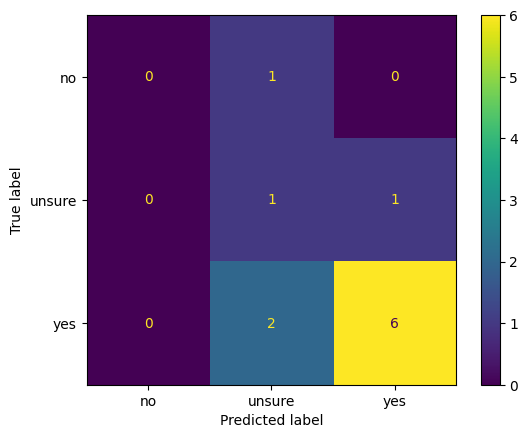

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(yva_true, yhat, display_labels=CLASS3)

In [11]:
import joblib, json, torch
import numpy as np
from pathlib import Path

def load_probe(aid_name: str, base_dir=EXPORT_DIR):
    d = Path(base_dir) / sanitize(aid_name)
    scaler = joblib.load(d / "scaler.joblib")
    clf    = joblib.load(d / "clf.joblib")
    meta   = json.load(open(d / "meta.json"))
    return scaler, clf, meta

@torch.no_grad()
def probe_predict_image(path, aid_name: str, tau=None, margin=None, ent_tau=None):
    scaler, clf, meta = load_probe(aid_name)
    # image -> CLIP feature (L2-normalized)
    x = preprocess(Image.open(path).convert("RGB")).unsqueeze(0).to(device)
    f = model.encode_image(x); f = (f / f.norm(dim=-1, keepdim=True)).cpu().numpy()  # [1, D]
    f_s = scaler.transform(f)                                                         # [1, D]
    probs = clf.predict_proba(f_s)                                                    # [1, 3]
    probs_t = torch.from_numpy(probs).float()
    # thresholds (default to meta)
    tau = meta["tau"] if tau is None else tau
    margin = meta["margin"] if margin is None else margin
    ent_tau = meta["ent_tau"] if ent_tau is None else ent_tau
    pred, accept, pmax, m, ent = accept_policy(probs_t, tau, margin, ent_tau)
    return {
        "probs": probs.flatten().tolist(),
        "pred": int(pred.item()),
        "accepted": bool(accept.item()),
        "pmax": float(pmax.item()),
        "margin": float(m.item()),
        "entropy": float(ent.item()),
        "class_names": meta["class_names"]
    }

# Example:
out = probe_predict_image(df_aid.loc[0,'path'], "Manual wheelchair")
out


{'probs': [0.9952195056091122, 0.004525136925989979, 0.00025535746489767917],
 'pred': 0,
 'accepted': True,
 'pmax': 0.9952195286750793,
 'margin': 0.9906944036483765,
 'entropy': 0.03130873665213585,
 'class_names': ['no', 'unsure', 'yes']}

In [12]:
# --- Linear probe per MobilityAid on frozen CLIP image features (robust to missing classes) ---

%pip install --quiet joblib

import os, json, joblib, numpy as np, torch
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from tqdm import tqdm

EXPORT_DIR = Path("/content/sidewalk_probe_exports")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

CLASS3 = ['no','unsure','yes']        # global order
ALL_LABELS = list(range(len(CLASS3))) # [0,1,2]

class AidDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)
    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        path = self.df.loc[i, 'path']
        y    = int(self.df.loc[i, 'label'])
        x    = preprocess(Image.open(path).convert("RGB"))
        return x, y

@torch.no_grad()
def extract_feats(dataloader):
    feats, ys = [], []
    for xb, yb in tqdm(dataloader, desc="Extract feats"):
        xb = xb.to(device)
        f = model.encode_image(xb)                       # [B, D]
        f = (f / f.norm(dim=-1, keepdim=True)).cpu().numpy()
        feats.append(f); ys.append(yb.numpy())
    return np.concatenate(feats, 0), np.concatenate(ys, 0)

def sanitize(name: str) -> str:
    return name.lower().replace(" ", "_").replace("/", "_").replace("-", "_")

def predict_proba_3(clf, X):
    """
    Expand sklearn predict_proba to fixed shape [N,3] in CLASS3 order.
    Handles cases where clf was fit on only 1 or 2 classes.
    """
    probs_raw = clf.predict_proba(X)            # [N, C']
    classes   = getattr(clf, "classes_", np.arange(probs_raw.shape[1]))  # e.g., array([0,2])
    out = np.zeros((probs_raw.shape[0], 3), dtype=float)
    out[:, classes] = probs_raw
    # tiny epsilon then renormalize for cosmetic stability
    out = (out + 1e-9) / (out.sum(axis=1, keepdims=True) + 3e-9)
    return out

def sweep_policy(probs_np, ytrue, taus=(0.40,0.45,0.50,0.55,0.60),
                 margins=(0.00,0.02,0.05,0.10), ent_tau=1.20, min_cov=0.70):
    """
    Returns best (tau, margin) by highest acc_on_cov, ties by higher coverage.
    If no row meets min_cov, choose best overall.
    """
    import pandas as pd
    probs = torch.from_numpy(probs_np).float()
    rows = []
    for tau in taus:
        for m in margins:
            pmax, pred = probs.max(dim=1)
            top2 = probs.topk(2, dim=1).values
            margin = top2[:,0]-top2[:,1]
            ent = -(probs * (probs.clamp_min(1e-12)).log()).sum(dim=1)
            accept = (pmax>=tau) & (margin>=m) & (ent<=ent_tau)
            mask = accept.numpy().astype(bool)
            cov = float(mask.mean())
            acc = accuracy_score(ytrue[mask], probs.numpy()[mask].argmax(1)) if mask.any() else None
            rows.append(dict(tau=tau, margin=m, coverage=cov, acc_on_cov=acc))
    df = pd.DataFrame(rows)
    pool = df[df.coverage >= min_cov] if (df.coverage >= min_cov).any() else df
    best = pool.sort_values(["acc_on_cov","coverage"], ascending=[False,False]).iloc[0].to_dict()
    return best, df

probe_rows = []

for aid in AIDS:
    df_aid = tallies[tallies['MobilityAid'] == aid].reset_index(drop=True)
    if len(df_aid) < 12:
        print(f"[{aid}] too few samples ({len(df_aid)}), skipping probe.")
        continue

    # Robust stratified split
    tr_df, va_df = stratified_split_min1(df_aid, label_col='label', test_size=0.2, random_state=42)
    if len(va_df) == 0:
        print(f"[{aid}] could not create a valid val split; skipping.")
        continue

    train_dl = DataLoader(AidDataset(tr_df), batch_size=64, shuffle=False, num_workers=2)
    val_dl   = DataLoader(AidDataset(va_df), batch_size=64, shuffle=False, num_workers=2)

    # Extract frozen features
    Xtr, ytr = extract_feats(train_dl)
    Xva, yva = extract_feats(val_dl)

    # Train logistic regression on top of features
    scaler = StandardScaler(with_mean=False)
    Xtr_s = scaler.fit_transform(Xtr)
    Xva_s = scaler.transform(Xva)

    clf = LogisticRegression(
        max_iter=2000, class_weight='balanced',
        n_jobs=-1, C=4.0, solver='lbfgs'  # leave multi_class default
    )
    clf.fit(Xtr_s, ytr)

    # Compute fixed-size [N,3] probabilities for consistent evaluation/policy
    probs_va3 = predict_proba_3(clf, Xva_s)

    # Plain report (use probs->argmax so labels are in [0,1,2] space)
    yhat = probs_va3.argmax(1)
    safe_report(yva, yhat, title=f"\n=== {aid} — Linear probe (plain argmax) ===")

    # Sweep tau/margin
    best, df_sweep = sweep_policy(
        probs_np=probs_va3,
        ytrue=yva,
        taus=(0.40,0.45,0.50,0.55,0.60),
        margins=(0.00,0.02,0.05,0.10),
        ent_tau=ENT_TAU,
        min_cov=0.70,
    )
    tau_star, margin_star = float(best["tau"]), float(best["margin"])

    # Apply chosen policy
    probs_t = torch.from_numpy(probs_va3).float()
    pred, accept, _, _, _ = accept_policy(probs_t, tau_star, margin_star, ENT_TAU)
    pred = pred.numpy()
    mask = accept.numpy().astype(bool)

    if mask.any():
        safe_report(yva[mask], pred[mask], title=f"=== {aid} — Linear probe + policy (τ={tau_star}, margin={margin_star}) ===")
        cov = float(mask.mean())
        acc_on_cov = accuracy_score(yva[mask], pred[mask])
    else:
        print(f"=== {aid} — policy accepted 0 samples; relax thresholds.")
        cov, acc_on_cov = 0.0, None

    # Export artifacts for the app
    subdir = EXPORT_DIR / sanitize(aid)
    subdir.mkdir(parents=True, exist_ok=True)
    joblib.dump(scaler, subdir / "scaler.joblib")
    joblib.dump(clf,    subdir / "clf.joblib")
    meta = {
        "aid": aid,
        "class_names": CLASS3,
        "cls_to_id": {c:i for i,c in enumerate(CLASS3)},
        "id_to_cls": {i:c for i,c in enumerate(CLASS3)},
        "tau": tau_star,
        "margin": margin_star,
        "ent_tau": ENT_TAU,
        "feature_norm": True,
        "backbone": f"open_clip::{model_name}::{pretrained}",
        "classes_seen": getattr(clf, "classes_", []).tolist()  # e.g., [0,2]
    }
    with open(subdir / "meta.json", "w") as f:
        json.dump(meta, f, indent=2)

    probe_rows.append({
        'aid': aid,
        'n': len(df_aid),
        'probe_acc': accuracy_score(yva, yhat),
        'probe_policy_cov': cov,
        'probe_policy_acc_on_cov': acc_on_cov,
        'tau_star': tau_star,
        'margin_star': margin_star
    })

probe_df = pd.DataFrame(probe_rows)
display(probe_df)
print(f"Artifacts exported to: {EXPORT_DIR}")

Extract feats: 100%|██████████| 1/1 [00:00<00:00,  1.07it/s]



=== Manual wheelchair — Linear probe (plain argmax) ===
Accuracy: 0.36363636363636365
              precision    recall  f1-score   support

          no      0.200     0.333     0.250         3
      unsure      0.500     0.500     0.500         4
         yes      0.500     0.250     0.333         4

    accuracy                          0.364        11
   macro avg      0.400     0.361     0.361        11
weighted avg      0.418     0.364     0.371        11

=== Manual wheelchair — Linear probe + policy (τ=0.4, margin=0.1) ===
Accuracy: 0.4444444444444444
              precision    recall  f1-score   support

          no      0.250     0.500     0.333         2
      unsure      0.500     0.500     0.500         4
         yes      1.000     0.333     0.500         3

    accuracy                          0.444         9
   macro avg      0.583     0.444     0.444         9
weighted avg      0.611     0.444     0.463         9



Extract feats: 100%|██████████| 1/1 [00:00<00:00,  1.23it/s]



=== Mobility scooter — Linear probe (plain argmax) ===
Accuracy: 0.36363636363636365
              precision    recall  f1-score   support

          no      0.400     0.500     0.444         4
      unsure      0.333     0.500     0.400         4
         yes      0.000     0.000     0.000         3

    accuracy                          0.364        11
   macro avg      0.244     0.333     0.281        11
weighted avg      0.267     0.364     0.307        11

=== Mobility scooter — Linear probe + policy (τ=0.6, margin=0.0) ===
Accuracy: 0.4444444444444444
              precision    recall  f1-score   support

          no      0.500     0.500     0.500         4
      unsure      0.400     0.667     0.500         3
         yes      0.000     0.000     0.000         2

    accuracy                          0.444         9
   macro avg      0.300     0.389     0.333         9
weighted avg      0.356     0.444     0.389         9



Extract feats: 100%|██████████| 1/1 [00:00<00:00,  1.22it/s]


...


=== Walker — Linear probe (plain argmax) ===
Accuracy: 0.36363636363636365
              precision    recall  f1-score   support

          no      0.500     0.250     0.333         4
      unsure      0.167     0.333     0.222         3
         yes      0.667     0.500     0.571         4

    accuracy                          0.364        11
   macro avg      0.444     0.361     0.376        11
weighted avg      0.470     0.364     0.390        11

=== Walker — Linear probe + policy (τ=0.4, margin=0.1) ===
Accuracy: 0.4
              precision    recall  f1-score   support

          no      0.500     0.333     0.400         3
      unsure      0.200     0.333     0.250         3
         yes      0.667     0.500     0.571         4

    accuracy                          0.400        10
   macro avg      0.456     0.389     0.407        10
weighted avg      0.477     0.400     0.424        10



Extract feats: 100%|██████████| 1/1 [00:00<00:00,  1.19it/s]


=== Walking cane — Linear probe (plain argmax) ===
Accuracy: 0.6363636363636364
              precision    recall  f1-score   support

          no      0.000     0.000     0.000         1
      unsure      0.250     0.500     0.333         2
         yes      0.857     0.750     0.800         8

    accuracy                          0.636        11
   macro avg      0.369     0.417     0.378        11
weighted avg      0.669     0.636     0.642        11

=== Walking cane — Linear probe + policy (τ=0.4, margin=0.0) ===
Accuracy: 0.6363636363636364
              precision    recall  f1-score   support

          no      0.000     0.000     0.000         1
      unsure      0.250     0.500     0.333         2
         yes      0.857     0.750     0.800         8

    accuracy                          0.636        11
   macro avg      0.369     0.417     0.378        11
weighted avg      0.669     0.636     0.642        11



,aid,n,probe_acc,probe_policy_cov,probe_policy_acc_on_cov,tau_star,margin_star
0,Manual wheelchair,52,0.363636,0.818182,0.444444,0.4,0.1
1,Mobility scooter,52,0.363636,0.818182,0.444444,0.6,0.0
2,Motorized wheelchair,52,0.272727,1.000000,0.272727,0.4,0.0
3,Walker,52,0.363636,0.909091,0.400000,0.4,0.1
4,Walking cane,52,0.636364,1.000000,0.636364,0.4,0.0


Artifacts exported to: /content/sidewalk_probe_exports


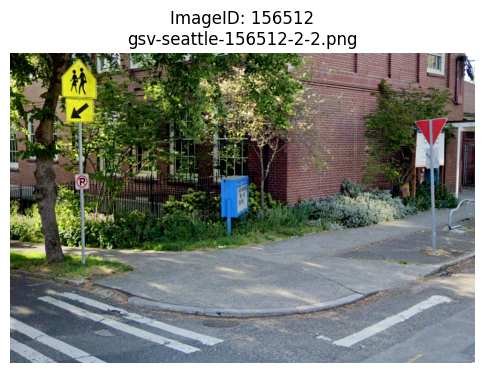

,MobilityAid,p_no,p_unsure,p_yes,decision,argmax,accepted,pmax,margin,entropy,dataset_label_name,true_majority,correct_argmax,correct_decision,note
0,Manual wheelchair,0.788,0.016,0.196,no,no,True,0.788,0.591,0.575,yes,None,False,False,None
1,Mobility scooter,0.000,0.001,0.999,yes,yes,True,0.999,0.999,0.007,yes,None,True,True,None
2,Motorized wheelchair,0.002,0.996,0.002,unsure,unsure,True,0.996,0.995,0.026,unsure,None,True,True,None
3,Walker,0.042,0.416,0.542,yes,yes,True,0.542,0.126,0.831,yes,None,True,True,None
4,Walking cane,0.000,0.002,0.997,yes,yes,True,0.997,0.995,0.020,yes,None,True,True,None


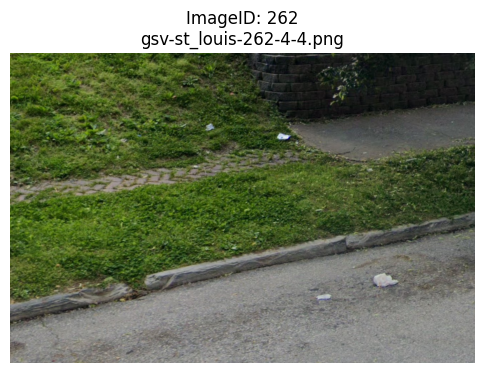

,MobilityAid,p_no,p_unsure,p_yes,decision,argmax,accepted,pmax,margin,entropy,dataset_label_name,true_majority,correct_argmax,correct_decision,note
0,Manual wheelchair,0.998,0.002,0.000,no,no,True,0.998,0.997,0.013,no,None,True,True,None
1,Mobility scooter,0.999,0.001,0.000,no,no,True,0.999,0.998,0.008,no,None,True,True,None
2,Motorized wheelchair,0.997,0.003,0.001,no,no,True,0.997,0.994,0.023,no,None,True,True,None
3,Walker,0.999,0.001,0.000,no,no,True,0.999,0.999,0.007,no,None,True,True,None
4,Walking cane,0.001,0.998,0.001,unsure,unsure,True,0.998,0.997,0.014,unsure,None,True,True,None


In [14]:
# ==== One-image inference (CLIP linear-probe) with per-aid table + GROUND TRUTH (dataset-aware) ====
import json, joblib, torch, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display
from PIL import Image

CLASS_NAMES = ['no','unsure','yes']
DEFAULT_TAU, DEFAULT_MARGIN, DEFAULT_ENT = 0.40, 0.00, 1.20
AIDS = getattr(globals(), 'AIDS', ['Manual wheelchair','Mobility scooter','Motorized wheelchair','Walker','Walking cane'])

def sanitize(name: str) -> str:
    return name.lower().replace(" ", "_").replace("/", "_").replace("-", "_")

def _find_row_for_image_id(image_id: int):
    # prefer test_df if available; else fall back to frame
    if 'test_df' in globals() and len(test_df):
        hit = test_df[test_df['ImageID'] == int(image_id)]
        if len(hit): return hit.iloc[0]
    assert 'frame' in globals(), "Neither test_df nor frame available. Rebuild frame first."
    hit = frame[frame['ImageID'] == int(image_id)]
    if len(hit) == 0:
        raise ValueError(f"ImageID {image_id} not found.")
    return hit.iloc[0]

@torch.no_grad()
def _encode_clip_feature(path: str):
    x = preprocess(Image.open(path).convert("RGB")).unsqueeze(0).to(device)
    f = model.encode_image(x)                         # [1, D]
    f = (f / f.norm(dim=-1, keepdim=True)).cpu().numpy()
    return f

def _load_probe(aid_name: str, base_dir=EXPORT_DIR):
    d = Path(base_dir) / sanitize(aid_name)
    scaler = joblib.load(d / "scaler.joblib")
    clf    = joblib.load(d / "clf.joblib")
    meta   = json.load(open(d / "meta.json"))
    # meta expected keys: tau, margin, ent_tau, classes_seen, target_mode
    meta.setdefault("tau", DEFAULT_TAU)
    meta.setdefault("margin", DEFAULT_MARGIN)
    meta.setdefault("ent_tau", DEFAULT_ENT)
    meta.setdefault("classes_seen", getattr(clf, "classes_", []).tolist())
    meta.setdefault("target_mode", "hard")
    return scaler, clf, meta

def _predict_proba_3(clf, X):
    """Expand sklearn probs to length-3 in global order [no, unsure, yes]."""
    probs_raw = clf.predict_proba(X)                  # [N, C']
    classes   = getattr(clf, "classes_", np.arange(probs_raw.shape[1]))
    out = np.zeros((probs_raw.shape[0], 3), dtype=float)
    out[:, classes] = probs_raw
    out = (out + 1e-9) / (out.sum(axis=1, keepdims=True) + 3e-9)
    return out

def _accept_policy_np(p, tau, margin, ent_tau):
    p = np.clip(np.asarray(p, float), 1e-12, 1.0); p /= p.sum()
    pmax = float(p.max())
    top2 = np.sort(p)[-2:]
    m = float(top2[-1] - top2[-2])
    ent = float(-(p * np.log(p)).sum())
    accept = (pmax >= tau) and (m >= margin) and (ent <= ent_tau)
    # If rejected, map to 'unsure' (index 1) to mirror your earlier behavior
    pred_idx = int(np.argmax(p)) if accept else 1
    return pred_idx, accept, pmax, m, ent, p

def _lookup_truth_rows(image_id: int):
    """
    Returns ground-truth rows for this image_id from 'tallies', if available.
    Columns expected from your dataset cell:
      majority, argmax_label, label_name (dataset policy output), label (int),
      y_soft_no/_unsure/_yes (may exist), etc.
    """
    if 'tallies' not in globals() or tallies is None or len(tallies) == 0:
        return None
    cols = ['ImageID','MobilityAid','majority','argmax_label','label_name','label',
            'y_soft_no','y_soft_unsure','y_soft_yes']
    cols = [c for c in cols if c in tallies.columns]
    gt = (tallies.loc[tallies['ImageID'] == int(image_id), cols]
                 .drop_duplicates().reset_index(drop=True))
    return gt if len(gt) else None

def predict_one_image_clip_probe(image_id=None, path=None,
                                 tau=None, margin=None, ent_tau=None,
                                 show=True, aids=None):
    """
    - choose by image_id (preferred) or direct path
    - returns (image_id, path, df_out)

    df_out columns (per MobilityAid):
      p_no, p_unsure, p_yes, decision, argmax, accepted, pmax, margin, entropy,
      true_majority, dataset_label_name, dataset_label, correct_argmax, correct_decision,
      seen_classes, note
    """
    assert 'preprocess' in globals() and 'model' in globals(), "CLIP model/preprocess not found."

    # Resolve path / image_id
    if path is None:
        assert image_id is not None, "Provide image_id or path."
        row = _find_row_for_image_id(int(image_id))
        path = str(row['path'])
        image_id = int(row['ImageID'])
    else:
        image_id = int(image_id) if image_id is not None else None

    # Encode CLIP feature once
    feat = _encode_clip_feature(path)                 # [1, D]

    # Optional: ground truth rows
    gt_df = _lookup_truth_rows(image_id) if image_id is not None else None

    recs = []
    for aid in (aids or AIDS):
        scaler, clf, meta = _load_probe(aid)
        f_s = scaler.transform(feat)                  # [1, D]
        probs = _predict_proba_3(clf, f_s)[0]         # [3]

        # thresholds: prefer per-aid meta unless overridden
        tau_eff  = meta["tau"]   if tau    is None else tau
        mar_eff  = meta["margin"]if margin is None else margin
        ent_eff  = meta["ent_tau"] if ent_tau is None else ent_tau

        pred_idx, accepted, pmax, m, ent, p = _accept_policy_np(probs, tau_eff, mar_eff, ent_eff)

        # Dataset ground truth (from your uncertainty-aware policy)
        true_majority = dataset_label_name = None
        dataset_label = None
        correct_argmax = correct_decision = None

        if gt_df is not None:
            g = gt_df[gt_df['MobilityAid'] == aid]
            if len(g):
                if 'majority' in g.columns:
                    true_majority = str(g.iloc[0]['majority'])
                if 'label_name' in g.columns:
                    dataset_label_name = str(g.iloc[0]['label_name']) if pd.notna(g.iloc[0]['label_name']) else None
                if 'label' in g.columns and pd.notna(g.iloc[0]['label']):
                    dataset_label = int(g.iloc[0]['label'])
                    correct_argmax   = (int(np.argmax(p)) == dataset_label)
                    correct_decision = (pred_idx == dataset_label)

        # Note when a probe was trained without all classes
        seen_classes = meta.get("classes_seen", [])
        note = None
        if isinstance(seen_classes, list) and len(seen_classes) < 3:
            missing = [i for i in range(3) if i not in seen_classes]
            if missing:
                missing_names = ", ".join(CLASS_NAMES[i] for i in missing)
                note = f"trained without: {missing_names}"

        recs.append({
            "MobilityAid": aid,
            "p_no": float(p[0]),
            "p_unsure": float(p[1]),
            "p_yes": float(p[2]),
            "decision": CLASS_NAMES[pred_idx],
            "argmax": CLASS_NAMES[int(np.argmax(p))],
            "accepted": bool(accepted),
            "pmax": pmax,
            "margin": m,
            "entropy": ent,
            "tau": tau_eff,
            "margin_thr": mar_eff,
            "ent_thr": ent_eff,
            "true_majority": true_majority,              # original crowd majority (for context)
            "dataset_label_name": dataset_label_name,    # label after your dataset policy (may be 'unsure' or None in soft mode)
            "dataset_label": dataset_label,              # int id used for training (if any)
            "correct_argmax": correct_argmax,
            "correct_decision": correct_decision,
            "seen_classes": seen_classes,
            "note": note,
            "target_mode": meta.get("target_mode", "hard")
        })

    df_out = pd.DataFrame(recs).sort_values("MobilityAid").reset_index(drop=True)

    if show:
        plt.figure(figsize=(6,6))
        plt.imshow(Image.open(path).convert("RGB")); plt.axis('off')
        ttl = f"ImageID: {image_id}" if image_id is not None else "Custom image"
        plt.title(ttl + f"\n{Path(path).name}")
        plt.show()

        df_show = df_out.copy()
        for c in ["p_no","p_unsure","p_yes","pmax","margin","entropy"]:
            df_show[c] = df_show[c].map(lambda v: f"{v:.3f}" if v is not None else "")
        display(df_show[[
            "MobilityAid","p_no","p_unsure","p_yes",
            "decision","argmax","accepted",
            "pmax","margin","entropy",
            "dataset_label_name","true_majority",
            "correct_argmax","correct_decision",
            "note"
        ]])

    return image_id, path, df_out

# ==== Example runs ====
# Random image
_ = predict_one_image_clip_probe(image_id=int((test_df if 'test_df' in globals() else frame).sample(1).iloc[0]['ImageID']))

# Specific ImageID
# _ = predict_one_image_clip_probe(image_id=12345)

# Direct path
# _ = predict_one_image_clip_probe(path="/content/Project_Sidewalk_Data/sidewalk-images/.../foo.jpg")

# Override thresholds (pass-through):
_ = predict_one_image_clip_probe(image_id=262, tau=0.0, margin=0.0)


In [15]:
# Zip the exported probes and download the zip to your computer (Colab)

import os, shutil, datetime
from google.colab import files

EXPORT_DIR = "/content/sidewalk_probe_exports"
ts = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
ZIP_PATH = f"/content/sidewalk_probe_exports.zip"

# Create the zip (overwrites if exists)
if os.path.exists(ZIP_PATH):
    os.remove(ZIP_PATH)
shutil.make_archive(base_name=ZIP_PATH.replace(".zip",""), format="zip", root_dir=EXPORT_DIR)

print("Created:", ZIP_PATH)
files.download(ZIP_PATH)

Created: /content/sidewalk_probe_exports.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>